In [2]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

In [3]:
import pandas as pd

fixed_results = pd.read_csv("results/fixed_runs.csv")
random_results = pd.read_csv("results/random_runs.csv")

In [11]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

display(df.groupby(['start_mode', 'algo', 'strategy'])['test_final_cash'].describe())
display(df.dtypes)
display(df.isnull().sum())
df['algo'].value_counts()
df['strategy'].value_counts()

count         mean           std  \
start_mode algo strategy                                            
fixed      abo  ema_independent   30.0  1482.449761  9.946911e+02   
                ema_shared        30.0  1815.812025  1.391740e+03   
                lma               30.0   683.138416  1.874051e+02   
                sma               30.0  1172.246028  1.247524e+01   
                weighted          30.0  4451.696568  8.170929e+02   
           aos  ema_independent   30.0  4271.851091  1.401703e+03   
                ema_shared        30.0  1894.032463  1.269024e+03   
                lma               30.0   794.096608  1.762895e+02   
                sma               30.0  1172.246028  1.247524e+01   
                weighted          30.0  4465.421449  8.302398e+02   
           gps  ema_independent   30.0  2328.667012  1.619273e+03   
                ema_shared        30.0  1831.888830  1.465627e+03   
                lma               30.0   879.139730  2.211375e+02   
                sma               30.0  1154.995486  2.163662e+02   
                weighted          30.0  2904.463557  1.852427e+03   
           mrfo ema_independent   30.0  1000.000000  0.000000e+00   
                ema_shared        30.0  1606.101452  1.366899e+03   
                lma               30.0   749.932663  2.003511e+02   
                sma               30.0  1180.275721  2.312607e-13   
                weighted          30.0  4329.082878  1.145655e+03   
           pso  ema_independent   30.0  3219.787103  1.460649e+03   
                ema_shared        30.0  2468.141499  2.176032e+03   
                lma               30.0   587.250644  1.358814e+02   
                sma               30.0  1129.063370  1.427064e+02   
                weighted          30.0  4813.352845  4.600434e+02   
           sos  ema_independent   30.0  3805.266377  1.285293e+03   
                ema_shared        30.0  2237.568295  1.698334e+03   
                lma               30.0   907.977724  0.000000e+00   
                sma               30.0  1180.275721  2.312607e-13   
                weighted          30.0  4580.572735  4.779724e+02   
random     abo  ema_independent   30.0  1571.547875  1.116958e+03   
                ema_shared        30.0  2408.182570  2.032666e+03   
                lma               30.0   742.495099  1.900496e+02   
                sma               30.0  1171.360121  1.461225e+01   
                weighted          30.0  4470.679547  9.703948e+02   
           aos  ema_independent   30.0  4463.359437  9.118198e+02   
                ema_shared        30.0  2559.524760  1.921990e+03   
                lma               30.0   804.376501  1.786373e+02   
                sma               30.0  1169.569464  1.333659e+01   
                weighted          30.0  4005.136358  1.513439e+03   
           gps  ema_independent   30.0  2659.173464  1.639742e+03   
                ema_shared        30.0  1819.939435  1.350677e+03   
                lma               30.0   939.179372  2.097797e+02   
                sma               30.0  1052.971553  2.542962e+02   
                weighted          30.0  1981.501366  1.767270e+03   
           mrfo ema_independent   30.0  1000.000000  0.000000e+00   
                ema_shared        30.0  1957.299567  2.195386e+03   
                lma               30.0   774.024220  1.953782e+02   
                sma               30.0  1180.275721  2.312607e-13   
                weighted          30.0  4158.145917  1.356560e+03   
           pso  ema_independent   30.0  3321.946476  1.404307e+03   
                ema_shared        30.0  2125.613944  1.431415e+03   
                lma               30.0   684.673058  1.762060e+02   
                sma               30.0  1063.073796  2.119179e+02   
                weighted          30.0  4464.471933  1.099632e+03   
           sos  ema_independent   30.0  4148.739220  1.006412e+03   
                ema_shared     

algo                     str
strategy                 str
run_id                 int64
start_mode               str
best_fitness         float64
final_cash           float64
test_final_cash      float64
epoch_count            int64
runtime_ms           float64
early_stopped           bool
best_params              str
hyperparams              str
equity_curve             str
test_equity_curve        str
dtype: object

algo                 0
strategy             0
run_id               0
start_mode           0
best_fitness         0
final_cash           0
test_final_cash      0
epoch_count          0
runtime_ms           0
early_stopped        0
best_params          0
hyperparams          0
equity_curve         0
test_equity_curve    0
dtype: int64

strategy
sma                360
lma                360
ema_shared         360
ema_independent    360
weighted           360
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set once at the top of your notebook — applies to everything below
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Kruskal Wallis

In [13]:
from scipy.stats import kruskal
import pandas as pd

results = []

for strategy in df['strategy'].unique():
    for init in df['start_mode'].unique():
        subset = df.query("strategy == @strategy and start_mode == @init")
        groups = [g['best_fitness'].values for _, g in subset.groupby('algo')]
        
        stat, p = kruskal(*groups)
        results.append({
            'strategy': strategy,
            'start_mode': init,
            'H_stat': stat,
            'p_value': p,
            'significant': p < 0.05
        })

results_df = pd.DataFrame(results)
print(results_df)

          strategy start_mode      H_stat       p_value  significant
0              sma      fixed  119.065414  4.950704e-24         True
1              sma     random  121.153144  1.788376e-24         True
2              lma      fixed  114.624910  4.310926e-23         True
3              lma     random  106.187071  2.617626e-21         True
4       ema_shared      fixed  114.929809  3.715893e-23         True
5       ema_shared     random  114.235384  5.211656e-23         True
6  ema_independent      fixed  151.732904  5.709724e-31         True
7  ema_independent     random  144.008592  2.513903e-29         True
8         weighted      fixed  120.694330  2.236958e-24         True
9         weighted     random  120.876481  2.046777e-24         True


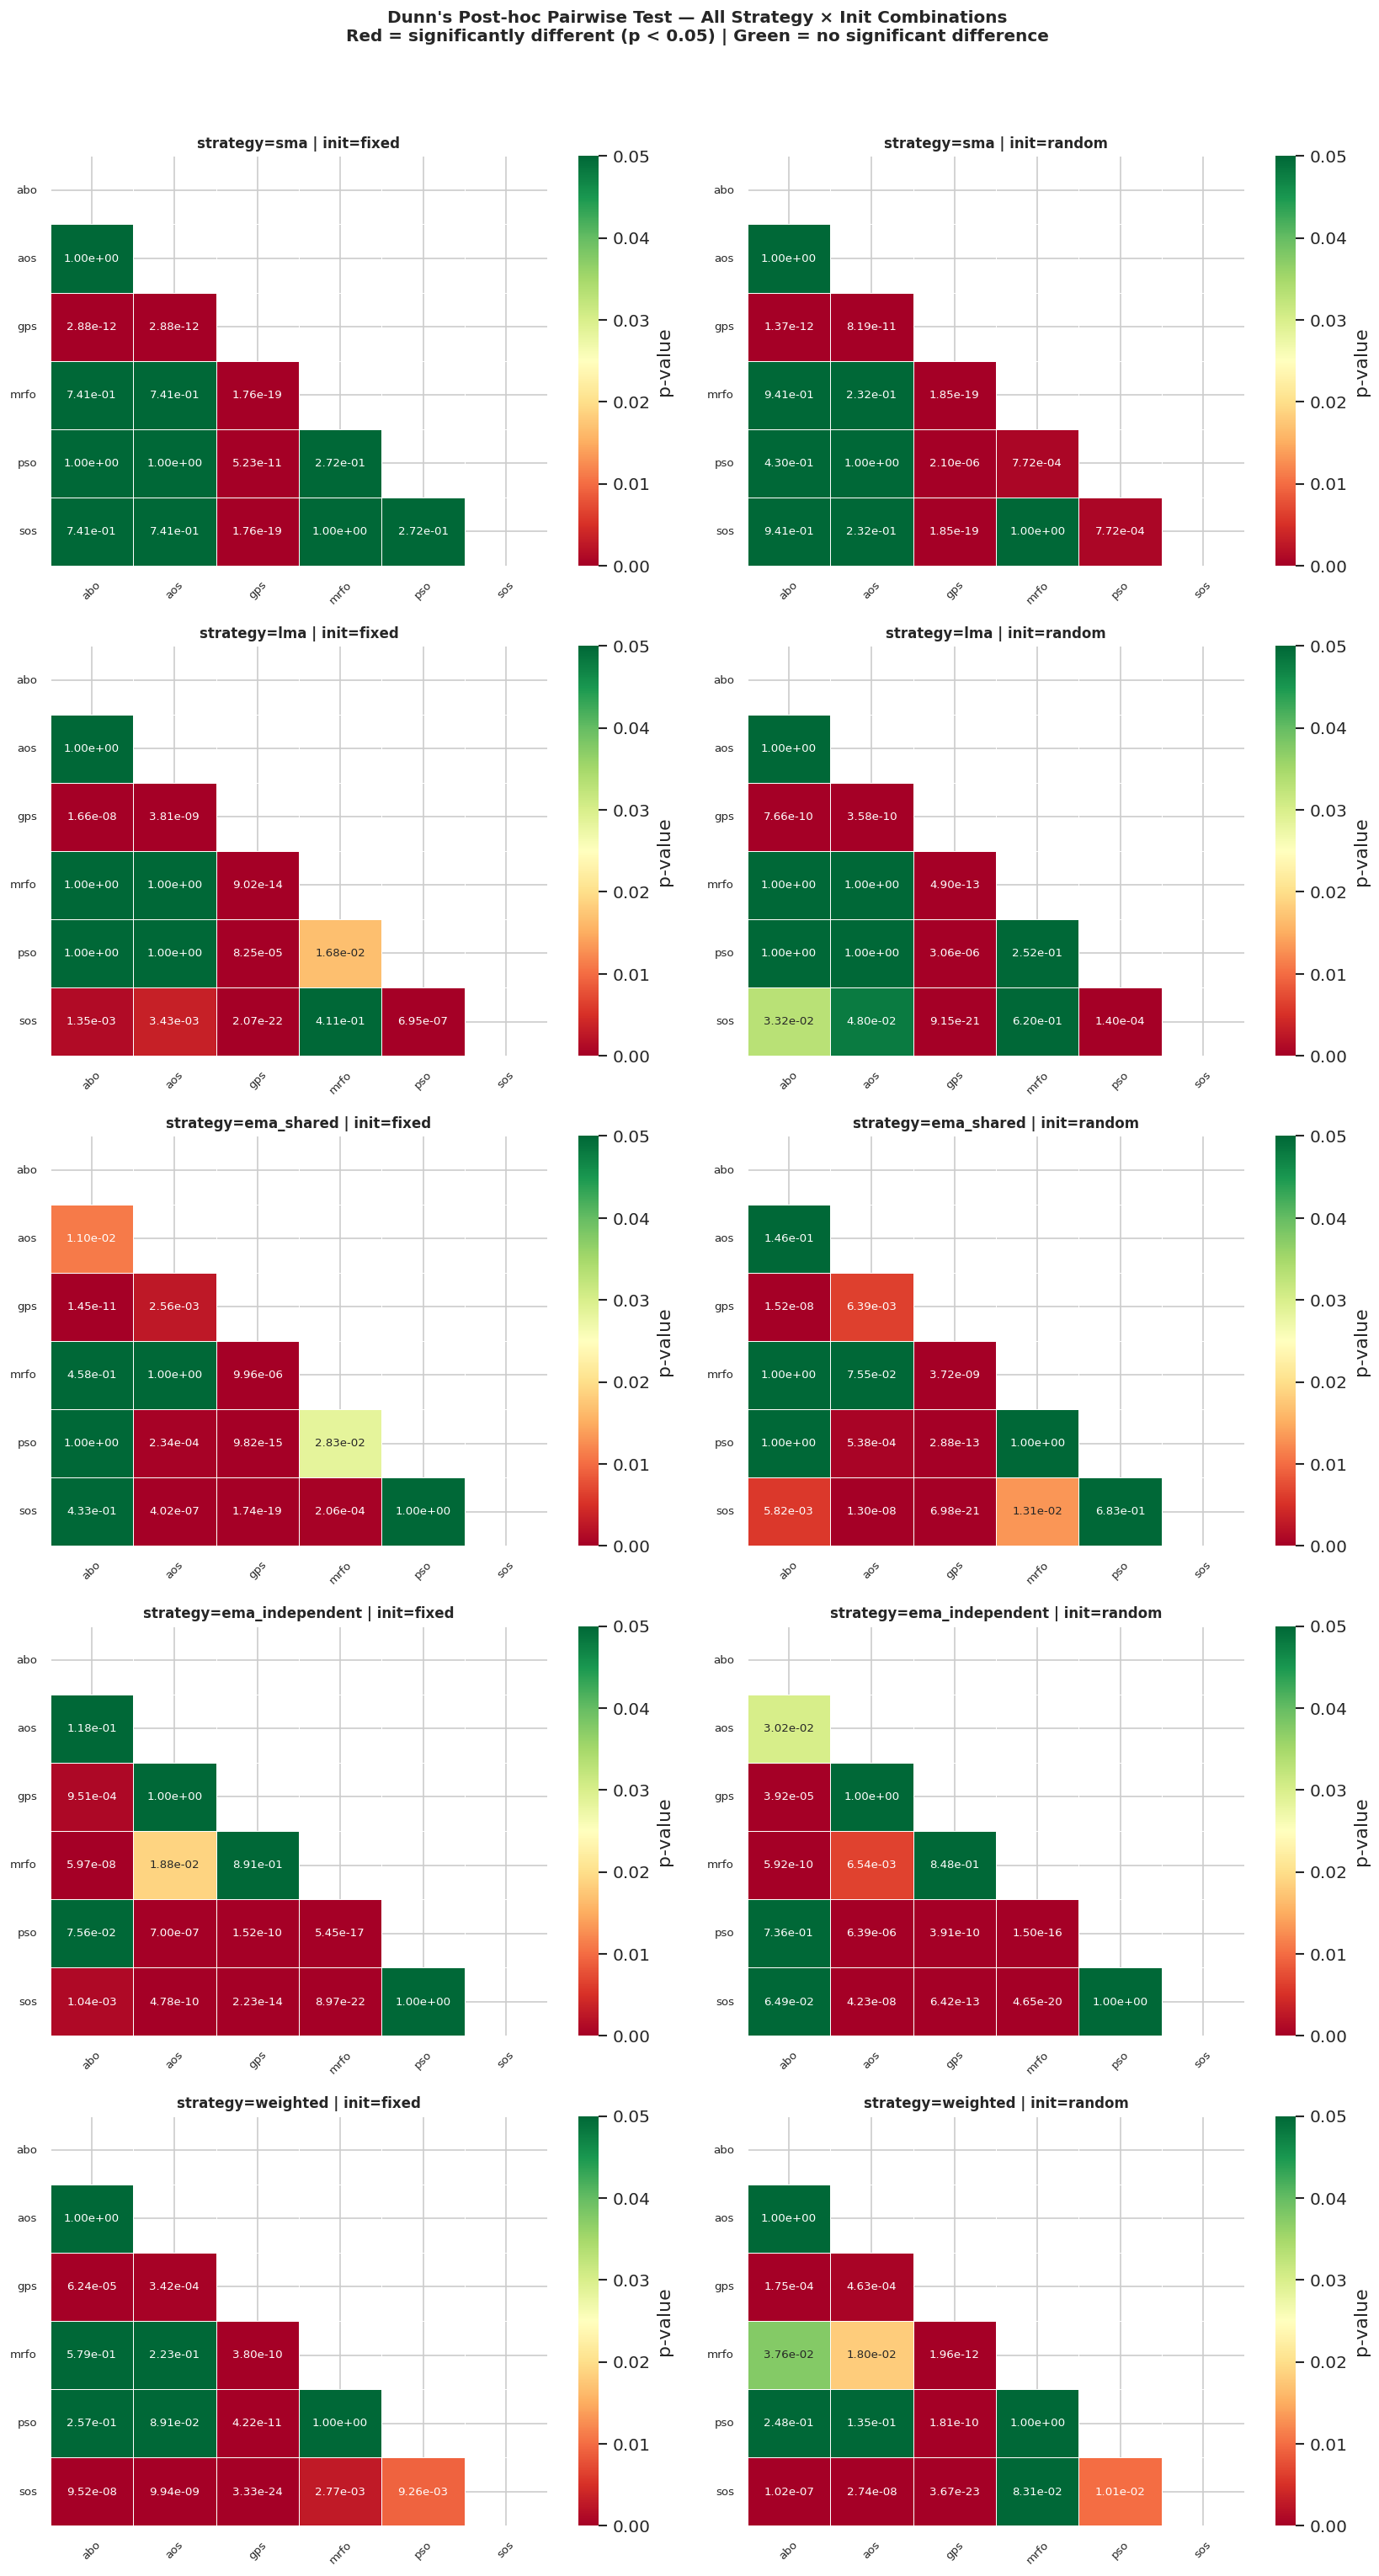

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scikit_posthocs import posthoc_dunn

strategies = df['strategy'].unique()
start_modes = df['start_mode'].unique()

combinations = [(s, m) for s in strategies for m in start_modes]
n_combos = len(combinations)

# Grid layout
ncols = 2
nrows = (n_combos + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

for i, (strategy, start_mode) in enumerate(combinations):
    subset = df.query("strategy == @strategy and start_mode == @start_mode")
    
    dunn_result = posthoc_dunn(
        subset,
        val_col='best_fitness',
        group_col='algo',
        p_adjust='bonferroni'
    )
    
    mask = np.triu(np.ones_like(dunn_result, dtype=bool))
    
    sns.heatmap(
        dunn_result,
        mask=mask,
        annot=True,
        fmt='.2e',
        cmap='RdYlGn',
        vmin=0,
        vmax=0.05,
        linewidths=0.5,
        ax=axes[i],
        cbar_kws={'label': 'p-value'},
        annot_kws={'size': 8}
    )
    
    axes[i].set_title(
        f"strategy={strategy} | init={start_mode}",
        fontsize=10, fontweight='bold'
    )
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', rotation=0, labelsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Dunn's Post-hoc Pairwise Test — All Strategy × Init Combinations\n"
    "Red = significantly different (p < 0.05) | Green = no significant difference",
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('dunn_pairwise_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
for strategy in df['strategy'].unique():
    for init in df['start_mode'].unique():
        subset = df.query("strategy == @strategy and start_mode == @init")
        medians = subset.groupby('algo')['best_fitness'].median().sort_values(ascending=False)
        print(f"\n{strategy} | {init}")
        display(medians)


sma | fixed


algo
gps     560.937297
abo    -932.497228
aos    -932.497228
mrfo   -932.497228
pso    -932.497228
sos    -932.497228
Name: best_fitness, dtype: float64


sma | random


algo
gps     585.147572
pso    -931.175319
aos    -932.497228
abo    -932.497228
mrfo   -932.497228
sos    -932.497228
Name: best_fitness, dtype: float64


lma | fixed


...

algo
gps      3983.504834
mrfo    -1000.000000
aos     -7579.218699
abo    -10623.588973
pso    -11840.345246
sos    -12043.424346
Name: best_fitness, dtype: float64


weighted | fixed


algo
gps      6136.075156
aos    -10705.403348
abo    -11366.222821
mrfo   -11762.864174
pso    -12355.898862
sos    -21605.887574
Name: best_fitness, dtype: float64


weighted | random


algo
gps      4595.384863
aos    -10670.006294
abo    -11264.840733
mrfo   -12340.451740
pso    -12612.260756
sos    -21605.887574
Name: best_fitness, dtype: float64

# Plot the bar for test_final_cash

In [ ]:

# Then your plot
fig, ax = plt.subplots(figsize=(12, 5))

medians = (df[df['start_mode'] == 'fixed']
           .groupby(['algo', 'strategy'])['test_final_cash']
           .median()
           .reset_index())

sns.barplot(
    data=medians,
    x='algo',
    y='test_final_cash',
    hue='strategy',
    palette='colorblind',   # distinguishable without relying on red/green
    ax=ax
)

# Reference line — starting capital
ax.axhline(1000, color='black', linewidth=0.8, linestyle='--', label='starting capital')

ax.set_title('Median test cash by algorithm and strategy (fixed init)', pad=12)
ax.set_xlabel('Algorithm')
ax.set_ylabel('Median test cash (USD)')
ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [ ]:
# Pivot so fixed and random are columns, then compute difference
diff = (df.groupby(['start_mode', 'algo', 'strategy'])['test_final_cash']
        .median()
        .unstack('start_mode')   # start_mode becomes columns
        .reset_index())

diff['diff'] = diff['random'] - diff['fixed']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=diff, x='algo', y='diff', hue='strategy', palette='colorblind', ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Random vs fixed init: difference in median test cash')
ax.set_ylabel('Random - Fixed (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

# Plot boxplot

In [ ]:
strategies_of_interest = ['sma', 'lma', 'ema_independent', 'weighted']

g = sns.FacetGrid(
    df[(df['start_mode'] == 'fixed') & 
       (df['strategy'].isin(strategies_of_interest))],
    col='strategy', col_wrap=2, height=4, aspect=1.3,
    sharey=False
)

g.map_dataframe(
    sns.boxplot,
    x='algo',
    y='test_final_cash',
    hue='algo',           # color by algo
    palette='colorblind',
    legend=True          # suppress per-subplot legends, we'll add one
)

g.set_xticklabels(rotation=45, ha='right')   # ha='right' stops labels from overlapping
g.set_titles(col_template='strategy = {col_name}')
g.set_axis_labels('Algorithm', 'Test cash (USD)')

# Add a shared legend
g.add_legend(title='Algorithm')

plt.tight_layout()

# Train vs Test Scatter

In [ ]:
sns.scatterplot(
    data=df[df['start_mode'] == 'fixed'],
    x='final_cash',
    y='test_final_cash',
    hue='algo',
    style='strategy',
    alpha=0.6
)

# Add the diagonal — points on this line have zero overfit
import numpy as np
lim = df['final_cash'].max()
plt.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='train = test')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('train cash')
plt.ylabel('test cash')

# Rank Stability

In [ ]:
# Compute rank within each strategy (per start_mode if you want to compare them)
fixed_df_ranked = df[df['start_mode'] == 'fixed'].copy()

fixed_df_ranked['rank'] = fixed_df_ranked.groupby('strategy')['test_final_cash'] \
                            .rank(ascending=False, method='average')

# Now plot — each dot is one run, spread by strategy
sns.stripplot(
    data=fixed_df_ranked,
    x='algo',
    y='rank',
    hue='strategy',
    dodge=True,       # separates hue groups horizontally
    alpha=0.5,
    jitter=True       # spreads overlapping points
)
plt.gca().invert_yaxis()  # rank 1 at top

# Runtime vs Performance

In [ ]:
# Aggregate first — you want one point per algo/strategy, not 30 overlapping points
agg = df[df['start_mode'] == 'fixed'].groupby(['algo', 'strategy']).agg(
    test_median=('test_final_cash', 'median'),
    runtime_median=('runtime_ms', 'median')
).reset_index()

sns.scatterplot(
    data=agg,
    x='runtime_median',
    y='test_median',
    hue='algo',
    style='strategy',
    s=100
)

# Annotate outliers so you can read the plot
for _, row in agg.iterrows():
    if row['runtime_median'] > 15000 or row['test_median'] > 4000:
        plt.annotate(
            f"{row['algo']}\n{row['strategy']}",
            (row['runtime_median'], row['test_median']),
            fontsize=7, alpha=0.7
        )

# Cash per Time

In [ ]:
agg['cash_per_ms'] = (agg['test_median'] - 1000) / agg['runtime_median']

sns.barplot(
    data=agg,
    x='algo',
    y='cash_per_ms',
    hue='strategy'
)
plt.ylabel('test profit per ms of runtime')

# Aggregate and Save

In [ ]:
agg_funcs = ["mean", "median", "std", lambda x: x.std() / x.mean(), "min", "max"]
agg_names  = ["mean", "median", "std", "cv", "min", "max"]

def summarise(df, cols):
    return (
        df.groupby(["strategy", "algo"])[cols]
        .agg(agg_funcs)
        .set_axis(
            pd.MultiIndex.from_product([cols, agg_names]),
            axis=1,
        )
    )

# Table 1 — cash performance
print("=== Fixed — Cash ===")
display(summarise(fixed_results, ["final_cash", "test_final_cash"]))

print("=== Random — Cash ===")
display(summarise(random_results, ["final_cash", "test_final_cash"]))

# Table 2 — runtime & epochs
print("=== Fixed — Runtime / Epochs ===")
display(summarise(fixed_results, ["runtime_ms", "epoch_count"]))

print("=== Random — Runtime / Epochs ===")
display(summarise(random_results, ["runtime_ms", "epoch_count"]))

In [ ]:
summary_fixed_cash    = summarise(fixed_results,  ["final_cash", "test_final_cash"])
summary_random_cash   = summarise(random_results, ["final_cash", "test_final_cash"])
summary_fixed_runtime = summarise(fixed_results,  ["runtime_ms", "epoch_count"])
summary_random_runtime = summarise(random_results, ["runtime_ms", "epoch_count"])

summary_fixed_cash.to_csv("results/summary_fixed_cash.csv")
summary_random_cash.to_csv("results/summary_random_cash.csv")
summary_fixed_runtime.to_csv("results/summary_fixed_runtime.csv")
summary_random_runtime.to_csv("results/summary_random_runtime.csv")

print("Summaries saved to results/")